# Breast Cancer Classification — Gaussian Naive Bayes
Dataset: Breast Cancer Dataset | Target: `diagnosis` (M = Malignant, B = Benign)

## Objective: Same classification task using Gaussian Naive Bayes.

## 1. Import Libraries

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

## 2. Load Data

In [2]:
# Load the breast cancer dataset
bcData = pd.read_csv(r"C:\Users\DELL\Downloads\Breast Cancer Dataset.csv")

## 3. Exploratory Data Analysis (EDA)

In [3]:
# Preview first 5 rows
bcData.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Shape, data types, and missing values
print("Shape:", bcData.shape)
print("\nData Types:")
print(bcData.dtypes)

Shape: (569, 33)

Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst        

In [5]:
# Convert diagnosis to categorical type
bcData['diagnosis'] = bcData['diagnosis'].astype('category')

# Statistical summary
bcData.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [6]:
# Class distribution — check for imbalance
bcData.groupby(['diagnosis']).count()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10716\717450905.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bcData.groupby(['diagnosis']).count()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,357,357,357,357,357,357,357,357,357,357,...,357,357,357,357,357,357,357,357,357,0
M,212,212,212,212,212,212,212,212,212,212,...,212,212,212,212,212,212,212,212,212,0


## 4. Data Preprocessing

In [7]:
# Drop 'id' column — it's a patient identifier, not a predictive feature
bcData = bcData.drop(labels='id', axis=1)
print("Shape after dropping 'id':", bcData.shape)

# Check for missing values
print("\nMissing Values:")
print(bcData.isnull().sum())

Shape after dropping 'id': (569, 32)

Missing Values:
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimensio

In [8]:
# Separate features (X) and target (y)
X = bcData.drop(labels='diagnosis', axis=1)
y = bcData['diagnosis']

# Fill missing values with column median
X = X.fillna(X.median())

# Normalize using z-score: each feature → mean=0, std=1
XScaled = X.apply(zscore)

# Replace any NaN introduced during z-score (e.g., zero-variance columns)
XScaled = XScaled.fillna(0)

# Split into 75% training and 25% testing
X_train, X_test, y_train, y_test = train_test_split(
    XScaled, y, test_size=0.25, random_state=1
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 426 rows | Test: 143 rows


## 5. Model Building — Gaussian Naive Bayes

In [9]:
# Gaussian NB assumes features follow a normal distribution within each class
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

GaussianNB()

## 6. Model Evaluation

In [10]:
# Predict on test set and compute accuracy
predicted_labels = NB_model.predict(X_test)
accuracy = NB_model.score(X_test, y_test)
print(f"Accuracy of Naive Bayes Model: {accuracy:.4f}")

Accuracy of Naive Bayes Model: 0.9441


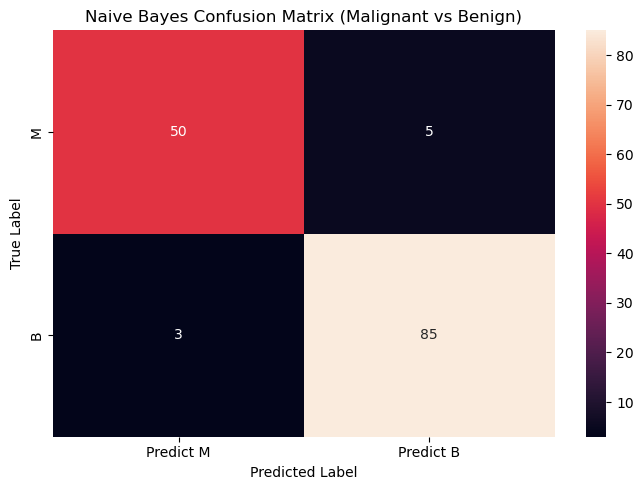

In [11]:
# Confusion matrix
cm = metrics.confusion_matrix(y_test, predicted_labels, labels=['M', 'B'])
df_cm = pd.DataFrame(cm, index=['M', 'B'], columns=['Predict M', 'Predict B'])

plt.figure(figsize=(7, 5))
sns.heatmap(df_cm, annot=True, fmt='g')
plt.title("Naive Bayes Confusion Matrix (Malignant vs Benign)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Conclusion: GNB achieves competitive accuracy with much lower compute cost. Z-score normalisation improved adherence to the Gaussian assumption.